# Fourier Captured Energy

This module tests the captured energy API, a core component of the functional Principal Component Analysis (fPCA) objective. The underlying mechanism involves pulling back a function through a learned isometry to maximize its expected Fourier coefficients under the measure $\nu$. This effectively concentrates the function's energy within the lowest frequencies.

A straightforward implementation relies on Monte Carlo integration. By sampling a batch of frequency indices from $\nu$ and averaging their inner products with the pulled-back function, we obtain an unbiased estimator of the captured energy. While this grid-free method naturally accommodates irregular domains, it inherently suffers from high variance and demands substantial sample complexity.

A more efficient alternative is to pull back the function and apply the Non-Uniform Fast Fourier Transform (NUFFT) to map the representation into the frequency domain. Assuming aliasing effects are negligible, the captured energy can then be quickly computed via a direct dot product between these transformed coefficients and the corresponding probability weights on the frequency grid.

Let's get the basic imports out of the way:

In [1]:
%load_ext autoreload
import torch
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import sys
sys.path.append('..')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_default_dtype(torch.float64)

First, sample a high frequency and low frequency signal, the aim is to compare their captured energy down the line with different methods:

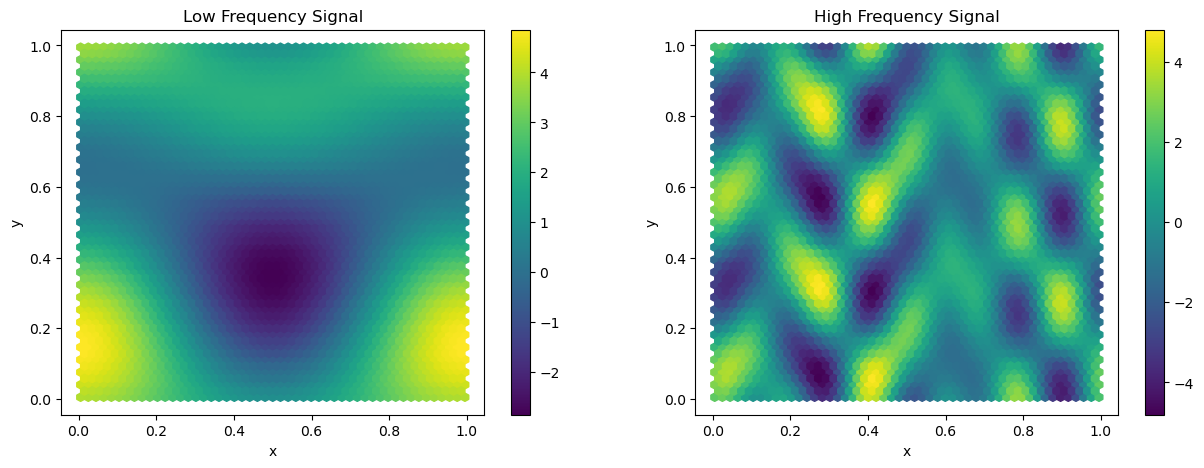

In [2]:
%autoreload 2
from infidictionary.dictionaries import FourierDictionary
from infidictionary.domain_samplers import SquareSampler

coords = SquareSampler(stratified=True, add_noise=False).sample(100).to(device)
fourier_basis = FourierDictionary(domain_dim=2, num_channels=1, index_geom_p=0.3)
high_freq_indices = torch.tensor([
    [3, 2],
    [-2, 2],
    [-5, -2],
    [3, -2],
])
low_freq_indices = torch.tensor([
    [0, -1],
    [-1, 0],
    [0, 0],
    [-1, 1],
])

low_frequency_signal = fourier_basis.get_atoms(
    coords.to(device), low_freq_indices.to(device),
).sum(dim=0)
high_frequency_atoms = fourier_basis.get_atoms(
    coords.to(device), high_freq_indices.to(device),
).sum(dim=0)

# plot the two signals
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.hexbin(
    coords[:,0].detach().cpu(), 
    coords[:,1].detach().cpu(), 
    C=low_frequency_signal.detach().cpu(), 
    gridsize=50, 
    cmap='viridis',
)
plt.colorbar()
plt.title('Low Frequency Signal')
plt.xlabel('x')
plt.ylabel('y')
plt.subplot(1, 2, 2)
plt.hexbin(
    coords[:,0].detach().cpu(), 
    coords[:,1].detach().cpu(), 
    C=high_frequency_atoms.detach().cpu(), 
    gridsize=50, 
    cmap='viridis',
)
plt.colorbar()
plt.title('High Frequency Signal')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [3]:
indices = fourier_basis.sample_indices(1000000)
# count the number of times each index in low_freq_indices is sampled
counts = torch.zeros(low_freq_indices.shape[0], device=device)
for i, idx in enumerate(low_freq_indices):
    counts[i] = (indices == idx).all(dim=1).sum()
print("Low frequency indices and their estimated pmfs:")
for idx, count in zip(low_freq_indices, counts):
    print(f"Index: {idx.cpu().numpy()}, Estimated PMF: {count.item()/1000000:.4f}")


Low frequency indices and their estimated pmfs:
Index: [ 0 -1], Estimated PMF: 0.0315
Index: [-1  0], Estimated PMF: 0.0318
Index: [0 0], Estimated PMF: 0.0896
Index: [-1  1], Estimated PMF: 0.0111


In [4]:
nyquist = 128
pmfs = fourier_basis.compute_grid_probas(nyquist=nyquist).to(coords.device) # (nyquist+1, nyquist+1  )
for idx in low_freq_indices:
    print(f"Index: {idx.cpu().numpy()}, Estimated PMF: {pmfs[idx[0]+nyquist, idx[1]+nyquist].item():.5f}")

Index: [ 0 -1], Estimated PMF: 0.03150
Index: [-1  0], Estimated PMF: 0.03150
Index: [0 0], Estimated PMF: 0.09000
Index: [-1  1], Estimated PMF: 0.01102


Next, we estimate the captured energy via Monte Carlo integration by sampling a large batch of Fourier basis functions and computing their Hilbert-space inner products. In expectation, the low-frequency signal will yield a greater captured energy than the high-frequency counterpart. However, the high variance inherent to this estimator means that the empirical distributions of the captured energies will exhibit substantial overlap when plotted as histograms:

100%|██████████| 1000/1000 [00:05<00:00, 178.72it/s]


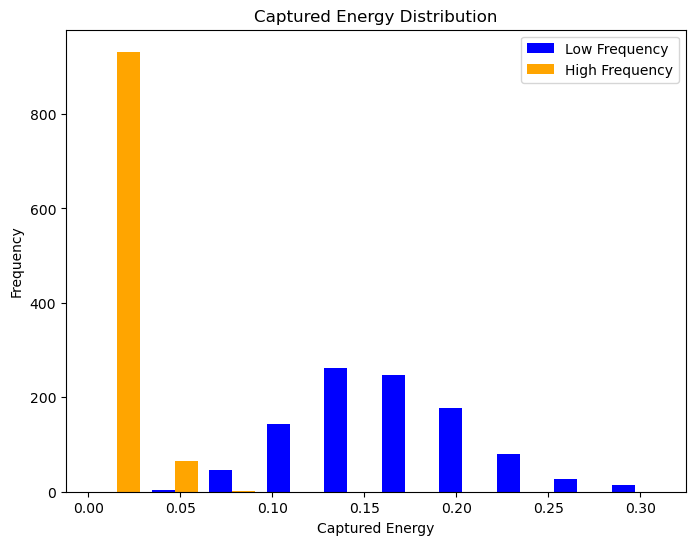

In [5]:

all_signals = torch.stack([low_frequency_signal, high_frequency_atoms])
all_captured_energies = []
batch_size = 64
n_draws = 1000

for _ in tqdm(range(n_draws)):
    captured_energy = fourier_basis.estimate_captured_energy(
        coords=coords,
        logabsdet=torch.zeros(coords.shape[0], device=device),  # logabsdet is not used in FourierDictionary, so we can just pass a dummy value
        values=all_signals, # (B, N, C)
        num_samples=batch_size,
        method='monte_carlo'
    )
    all_captured_energies.append(captured_energy.cpu())
all_captured_energies = torch.stack(all_captured_energies)  # (num_trials, B)
# plot a histogram of the captured energies with different colors for the low and high frequency signals
plt.figure(figsize=(8, 6))
plt.hist(all_captured_energies,color=['blue', 'orange'], label=['Low Frequency', 'High Frequency'])
plt.title('Captured Energy Distribution')
plt.xlabel('Captured Energy')
plt.ylabel('Frequency')
plt.legend()
plt.show()

Next, we can try the method with NUFFT to compare the results:

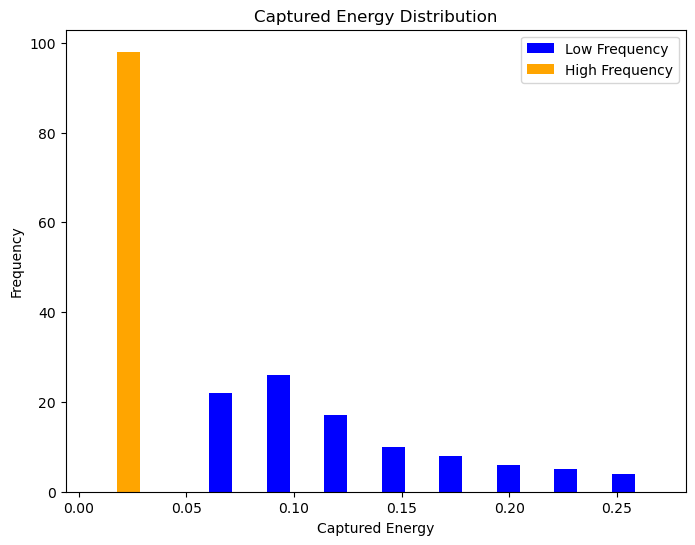

In [6]:
all_signals = torch.stack([low_frequency_signal, high_frequency_atoms])
all_captured_energies = []
all_dfts = []
for nyquist_freq in range(32, 130):
    captured_energy, dft, all_probas = fourier_basis.estimate_captured_energy(
        coords=coords.to(device),
        logabsdet=torch.zeros(coords.shape[0], device=device),  # logabsdet is not used in FourierDictionary, so we can just pass a dummy value
        values=all_signals.to(device), # (B, N, C)
        nyquist=nyquist_freq,
        method='nufft',
        return_dft=True,
    )
    all_dfts.append(dft.detach().cpu())
    all_captured_energies.append(captured_energy.detach().cpu())
all_captured_energies = torch.stack(all_captured_energies)  # (num_trials, B)
# plot a histogram of the captured energies with different colors for the low and high frequency signals
plt.figure(figsize=(8, 6))
plt.hist(all_captured_energies,color=['blue', 'orange'], label=['Low Frequency', 'High Frequency'])
plt.title('Captured Energy Distribution')
plt.xlabel('Captured Energy')
plt.ylabel('Frequency')
plt.legend()
plt.show()

**TODO:** there's probably something wrong here because the scales should be the same:

In [7]:
(all_dfts[0][0].abs() ** 2).sum()

tensor(4.5501, dtype=torch.float32)

In [8]:
(all_signals * all_signals).mean()

tensor(4.0000, device='cuda:0')